In [ ]:
# Step 1 - Import Required Library -The pandas library is imported(the pd is an alias for pandas - similar to database in sql) - click run

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
# Step 2 - # read_csv File Data to be loaded into pandas Data Frame (similar to tables in sql) - click run


In [4]:
myElection_Donations = pd.read_csv("/anvil/projects/tdm/data/election/itcont1980.txt", header=None, sep='|') #header=None: Indicates that the file does not contain column headers. Without this, Pandas will assume the first row contains column names.
#sep='|': Specifies that the columns in the file are separated by a pipe (|) character.

In [5]:
# Step 3 - Assign Column Names 

In [6]:
myElection_Donations.columns = ["CMTE_ID", "AMNDT_IND", "RPT_TP", "TRANSACTION_PGI", "IMAGE_NUM", "TRANSACTION_TP", "ENTITY_TP", "NAME", "CITY", "STATE", "ZIP_CODE", "EMPLOYER", "OCCUPATION", "TRANSACTION_DT", "TRANSACTION_AMT", "OTHER_ID", "TRAN_ID", "FILE_NUM", "MEMO_CD", "MEMO_TEXT", "SUB_ID"]
#myElection_Donations.columns: Replaces the default column names (e.g., integers) with meaningful names based on the dataset's structure

In [7]:
# Step 4 - # Display first 5 rows of data from the election donations data frame(similar to Top 5 in sql) - click run

In [8]:
myElection_Donations.head()

,CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,...,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID
0,C00078279,A,M11,P,80031492155,22Y,NaN,"MCKENNON, K R",MIDLAND,MI,...,NaN,NaN,10031979.0,400,NaN,NaN,NaN,NaN,CONTRIBUTION REF TO INDIVIDUAL,3062020110011466469
1,C00078279,A,M11,NaN,79031415137,15,NaN,"OREFFICE, P",MIDLAND,MI,...,DOW CHEMICAL CO,NaN,10261979.0,1500,NaN,NaN,NaN,NaN,NaN,3061920110000382948
2,C00078279,A,M11,NaN,79031415137,15,NaN,"DOWNEY, J",MIDLAND,MI,...,DOW CHEMICAL CO,NaN,10261979.0,300,NaN,NaN,NaN,NaN,NaN,3061920110000382949
3,C00078279,A,M11,NaN,79031415137,15,NaN,"BLAIR, E",MIDLAND,MI,...,DOW CHEMICAL CO,NaN,10261979.0,1000,NaN,NaN,NaN,NaN,NaN,3061920110000382950
4,C00078287,A,Q1,NaN,79031231889,15,NaN,"BLANCHARD, JOHN A",CHICAGO,IL,...,NaN,NaN,3201979.0,200,NaN,NaN,NaN,NaN,NaN,3061920110000383914


In [9]:
def myindycities (myyear: int) -> pd.Series:
    """
    The myindycities function takes a year as the input,
    and returns a Series of length 10 containing the top 10 cities in Indiana 
    according to the sum of the donation amounts given in each city, during that year.

    Args:
    myyear (int): This is a year as the input

    Returns:
    myindycities (pd.Series): This is a Series of length 10 containing the top 10 Indiana cities by donation amount.
    """
    mydonate = pd.read_csv("/anvil/projects/tdm/data/election/itcont" + str(myyear) + ".txt", 
                          header=None, sep='|', usecols=[8, 9, 14], encoding='Windows-1252')
    mydonate.columns = ["CITY", "STATE", "TRANSACTION_AMT"]
    indiana_donations = mydonate[mydonate['STATE'] == 'IN']
    myindycities = indiana_donations.groupby('CITY')['TRANSACTION_AMT'].sum().sort_values(ascending=False).head(10)
    return myindycities


In [10]:
# Display results from the myindycities function for the year 1980 and display the top 10 Indiana cities by total donation amount for that year
myindycities(1980)

CITY
INDIANAPOLIS    753547
MUNCIE          159897
ELKHART         111385
EVANSVILLE       94605
FORT WAYNE       87115
CARMEL           85872
INDPLS           76396
FT WAYNE         70174
SOUTH BEND       68332
LAFAYETTE        49851
Name: TRANSACTION_AMT, dtype: int64

In [11]:
# Display results from the myindycities function for the year 1986 and display the top 10 Indiana cities by total donation amount for that year
myindycities(1986)

CITY
INDIANAPOLIS    995379
FORT WAYNE      149194
MUNCIE          100433
ELKHART         100350
EVANSVILLE       84815
SOUTH BEND       81841
CARMEL           75993
TERRE HAUTE      62361
ZIONSVILLE       50900
COLUMBUS         40400
Name: TRANSACTION_AMT, dtype: int64

In [12]:
# Display results from the myindycities function for the year 1992 and display the top 10 Indiana cities by total donation amount for that year
myindycities(1992)

CITY
INDIANAPOLIS    2583618
FORT WAYNE       524980
CARMEL           384683
EVANSVILLE       308566
SOUTH BEND       274397
MUNCIE           251164
ELKHART          196432
COLUMBUS         143096
BLOOMINGTON      121733
ZIONSVILLE        94370
Name: TRANSACTION_AMT, dtype: int64

In [13]:
# Display results from the myindycities function for the year 1980 and display the top 10 Indiana cities by total donation amount for that year
myevenIndycities = [myyear for myyear in range(1984,1995,2)] 
## myIndyresults contains the top 10 Indiana cities by donation amount for each of those years
myIndyresults = [myindycities(myyear) for myyear in myevenIndycities]

In [14]:
# Display the list containing the top 10 Indiana cities by donation amount for even years from 1984 - 1995
myIndyresults

[CITY
 INDIANAPOLIS    511935
 MUNCIE          104260
 ELKHART          93171
 FORT WAYNE       80882
 INDPLS           76520
 SOUTH BEND       68387
 EVANSVILLE       65250
 CARMEL           53200
 TERRE HAUTE      52650
 FT WAYNE         44665
 Name: TRANSACTION_AMT, dtype: int64,
 CITY
 INDIANAPOLIS    995379
 FORT WAYNE      149194
 MUNCIE          100433
 ELKHART         100350
 EVANSVILLE       84815
 SOUTH BEND       81841
 CARMEL           75993
 TERRE HAUTE      62361
 ZIONSVILLE       50900
 COLUMBUS         40400
 Name: TRANSACTION_AMT, dtype: int64,
 CITY
 INDIANAPOLIS    1231113
 FORT WAYNE       189037
 SOUTH BEND       185771
 ELKHART          167767
 MUNCIE           156335
 CARMEL           148438
 COLUMBUS         124308
 EVANSVILLE        90893
 ZIONSVILLE        88735
 TERRE HAUTE       77425
 Name: TRANSACTION_AMT, dtype: int64,
 CITY
 INDIANAPOLIS    1637113
 FORT WAYNE       708475
 CARMEL           210213
 MUNCIE           206123
 SOUTH BEND       179821
 COLUMB

Text(0.5, 1.0, '1994 Indiana Donations by City')

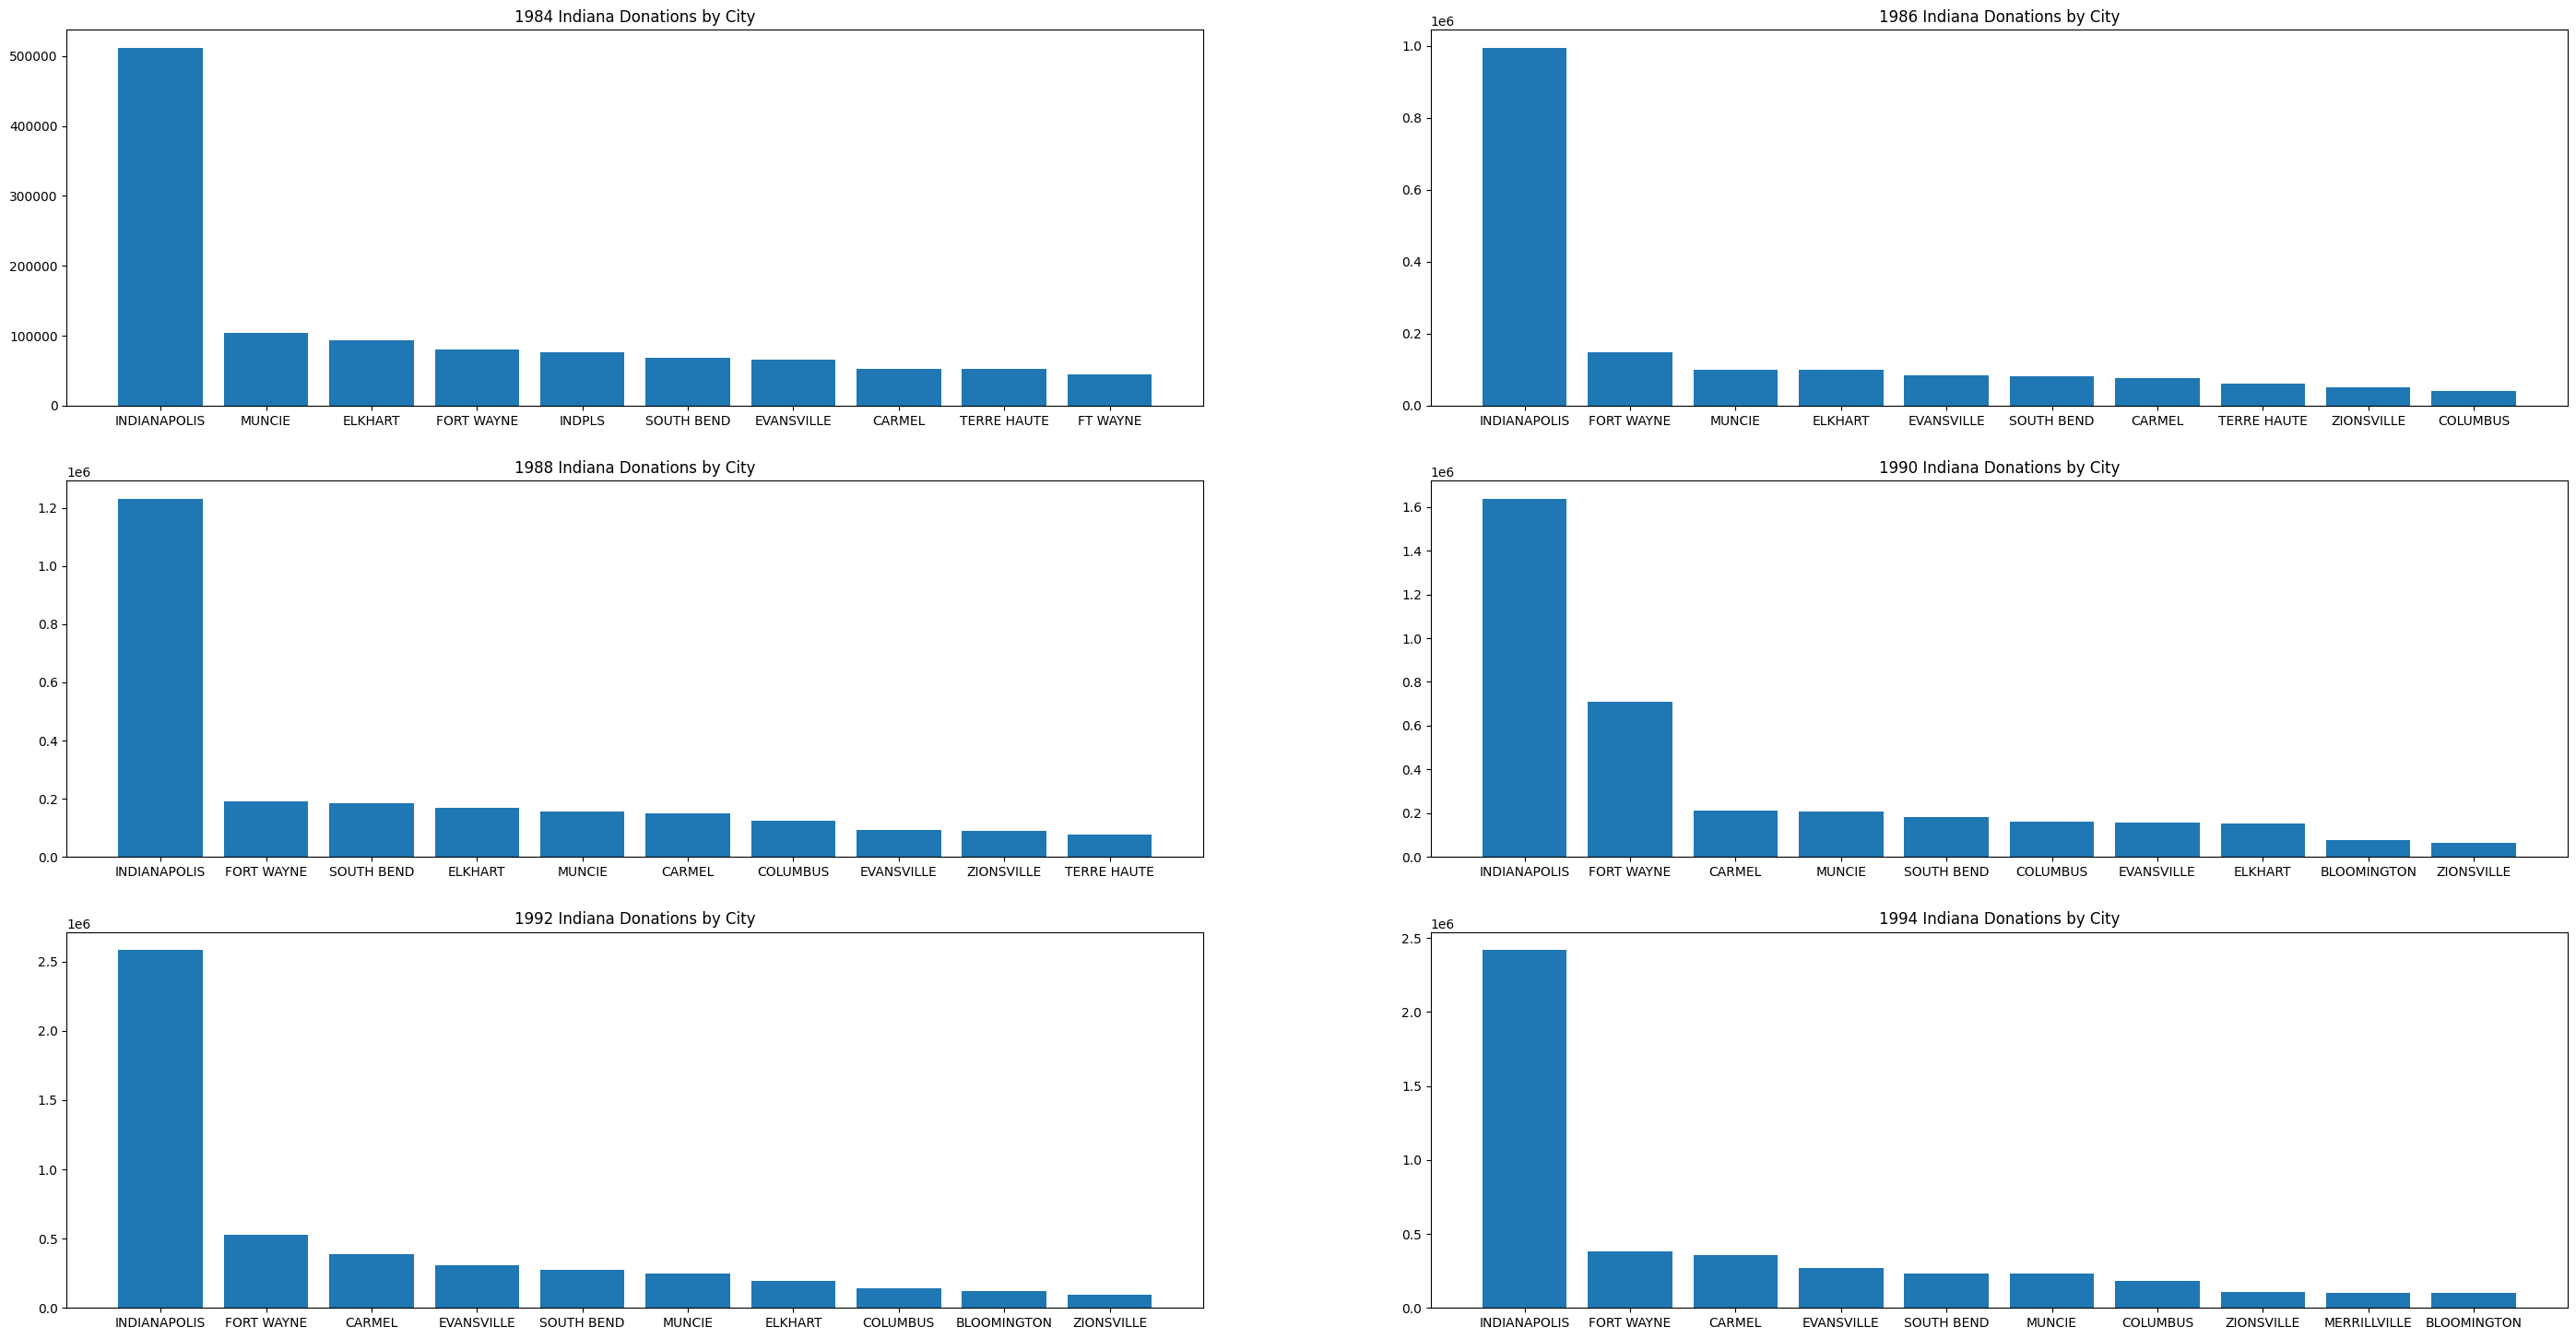

In [19]:
# Get results for even-numbered years from 1984 to 1994
results1984 = myindycities(1984)
results1986 = myindycities(1986)
results1988 = myindycities(1988)
results1990 = myindycities(1990)
results1992 = myindycities(1992)
results1994 = myindycities(1994)

# Create a 3×2 grid of subplots with appropriate size
fig, axs = plt.subplots(3, 2, figsize=(35,18))

# Plot the results for each year in the appropriate subplot position
axs[0, 0].bar(results1984.index, results1984) 
axs[0, 0].set_title("1984 Indiana Donations by City")

axs[0, 1].bar(results1986.index, results1986)
axs[0, 1].set_title("1986 Indiana Donations by City")

axs[1, 0].bar(results1988.index, results1988)
axs[1, 0].set_title("1988 Indiana Donations by City")

axs[1, 1].bar(results1990.index, results1990)
axs[1, 1].set_title("1990 Indiana Donations by City")

axs[2, 0].bar(results1992.index, results1992)
axs[2, 0].set_title("1992 Indiana Donations by City")

axs[2, 1].bar(results1994.index, results1994)
axs[2, 1].set_title("1994 Indiana Donations by City")